In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
library(randomForest)
library(pheatmap)
library(dbscan)
library(scDblFinder)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


载入需要的程序包：iterators


载入程序包：‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


载入程序包：‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



载入程序包：‘dbscan’


The following object is masked from ‘package:stats’:

    as.dendrogram


载入需要的程序包：SingleCellExperiment

载入需要的程序包：SummarizedExperiment

载入需要的程序包：MatrixGenerics

载入需要的程序包：matrixStats


载入程序包：‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



载入程序包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAn

In [2]:
data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/vta_new-1.h5ad')
# data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/vta.h5ad')
seurat = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)

seurat


Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


An object of class Seurat 
20357 features across 100837 samples within 1 assay 
Active assay: RNA (20357 features, 0 variable features)
 1 layer present: counts

In [3]:
table(seurat$Library)


cDNA-250114091 cDNA-250114092 cDNA-250114093 cDNA-250114094 cDNA-250114095 
         14498          14402          14146          13986          14738 
cDNA-250114096 cDNA-250114097 
         14845          14222 

In [ ]:
seurat$countFeatureRatio <- seurat$nCount_RNA / seurat$nFeature_RNA
`MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")`
seurat[["percent.mt"]] <- colSums(x = GetAssayData(object = seurat, assay = "RNA", layer = "counts")
    [MTGenes, , drop = FALSE])/seurat[[paste0("nCount_","RNA")]] * 100

In [4]:
obj = seurat
obj <- obj %>% FindVariableFeatures(verbose = FALSE)

.sce <- Seurat::as.SingleCellExperiment(obj) %>% suppressWarnings
.tbl <- scDblFinder::scDblFinder(.sce,nfeatures = VariableFeatures(obj), samples="Library",returnType = "table",verbose = FALSE)[colnames(obj),c("score","class")] %>% setNames(c('doublet_score','doublet_class'))
obj@meta.data <- obj@meta.data %>% cbind(.tbl)


Warning message in .checkSCE(sce, coerce = is.null(samples)):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in .checkSCE(sce, coerce = is.null(samples)):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in .checkSCE(sce, coerce = is.null(samples)):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in .checkSCE(sce, coerce = is.null(samples)):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in .checkSCE(sce, coerce = is.null(samples)):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in .checkSCE(sce, coerce = is.null(samples)):
“So

In [5]:
table(obj$doublet_class)


doublet singlet 
   8739   92098 

In [8]:
table(seurat_1$Library)


cDNA-250114091 cDNA-250114092 cDNA-250114093 cDNA-250114094 cDNA-250114095 
          8577           8892           9378           9296           9899 
cDNA-250114096 cDNA-250114097 
         10123           9780 

In [9]:
obj  ### raw
seurat  ### QC  n_feature_RNA > 800
seurat_1  ### doublet filte 

An object of class Seurat 
20357 features across 100837 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

An object of class Seurat 
20357 features across 85566 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

An object of class Seurat 
20357 features across 77297 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

In [15]:
1 - ncol(seurat)/ncol(obj)
1 - ncol(seurat_1)/ncol(obj)
1 - ncol(seurat_1)/ncol(obj) - (1 - ncol(seurat)/ncol(obj))

[1] 0.1514424

[1] 0.2334461

[1] 0.08200363

In [16]:
obj

An object of class Seurat 
20357 features across 100837 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

In [19]:
obj_1 = subset(
    obj,
    nFeature_RNA > 800 
    & percent.mt < 5 
    & countFeatureRatio > 1.2
    & countFeatureRatio < 10000
    & doublet_class	== "singlet" 
    )

obj_2 = subset(
    obj_1,
    nCount_RNA < 50000
    )

obj_1
obj_2

An object of class Seurat 
20357 features across 77698 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

An object of class Seurat 
20357 features across 77297 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

In [ ]:
seurat = subset(obj, 
nFeature_RNA > 800 
& percent.mt < 5 
& countFeatureRatio > 1.2
& countFeatureRatio < 10000
& nCount_RNA < 50000)

seurat_1 =subset(seurat ,doublet_class	== "singlet" )
 

cellNum1 = ncol(seurat_1)
cellNum2 = ncol(obj)
message("Filter ratio: ", cellNum1/cellNum2)
sample_cellNum <- table(seurat$Library)
sample_cellNum_filter <- table(seurat_1$Library)
sample_ratial <- sample_cellNum_filter / sample_cellNum
sample_ratial

Filter ratio: 0.766553943492964




cDNA-250114091 cDNA-250114092 cDNA-250114093 cDNA-250114094 cDNA-250114095 
     0.8991260      0.8994197      0.8941808      0.9065319      0.9021816 
cDNA-250114096 cDNA-250114097 
     0.9101178      0.9122762 

In [6]:
saveRDS(seurat_1, file = "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/Macaque_VTA_QC_.qs")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


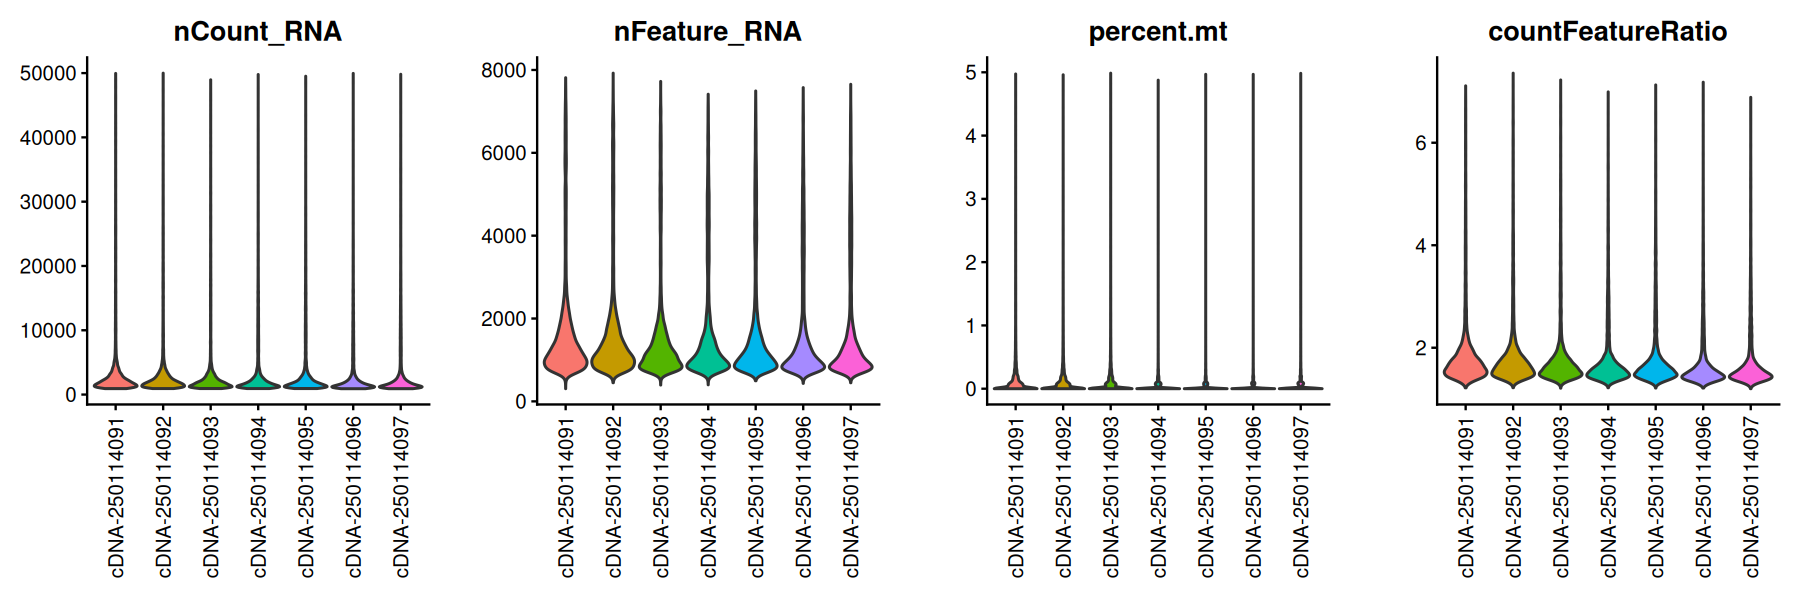

In [6]:
Idents(seurat_1) = "Library"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(seurat_1, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [7]:
SCTseurat = SCTransform(
    seurat_1, assay="RNA",
    ncells=ncol(seurat_1[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

Running SCTransform on assay: RNA



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19386 by 90341

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 90341 cells

Found 40 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19386 genes

Computing corrected count matrix for 19386 genes

Calculating gene attributes

Wall clock passed: Time difference of 7.371954 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT



In [8]:
SCTseurat = SCTseurat %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = 0.5, random.seed = 111) %>%
    RunUMAP(dims = 1:25,umap.method = "umap-learn")

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


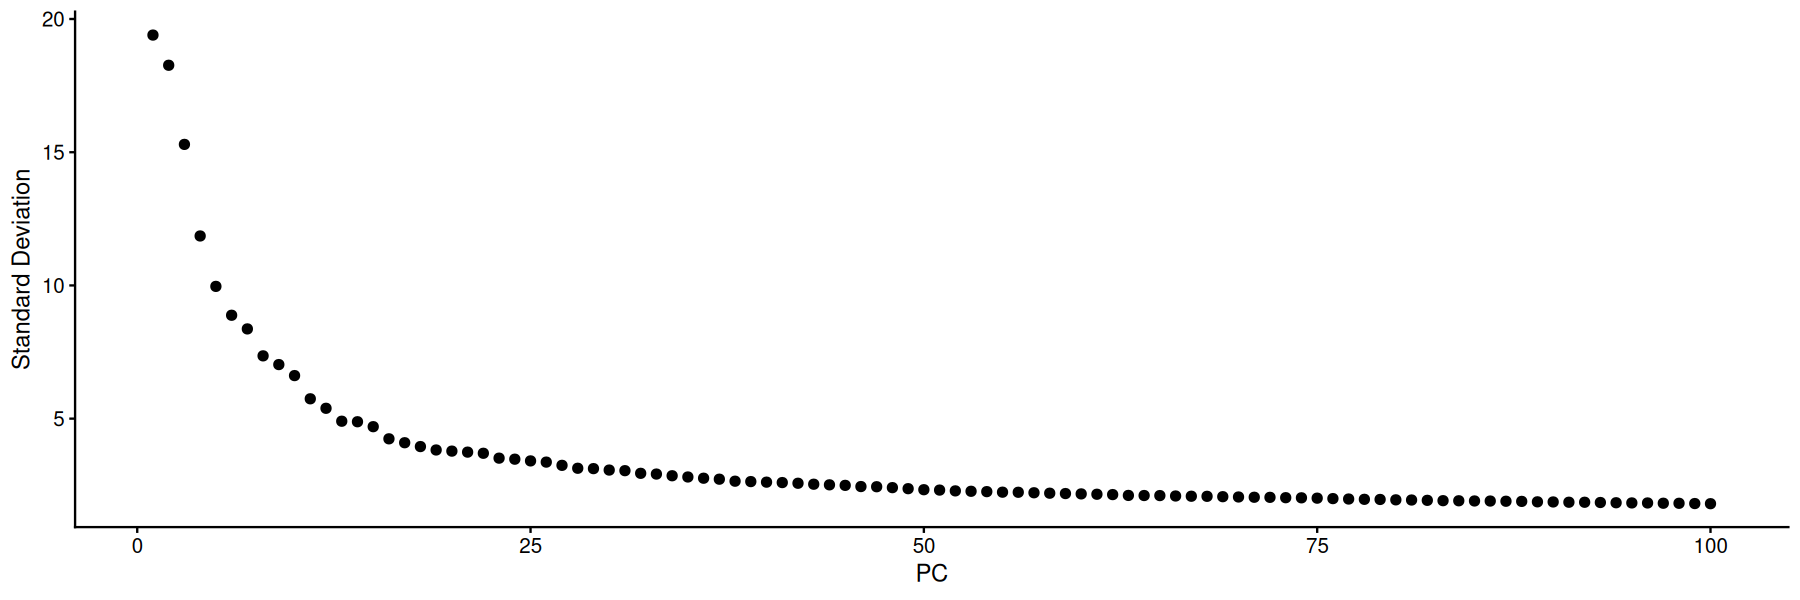

In [10]:
plot <- ElbowPlot(SCTseurat,ndims =100 , reduction = 'pca')
plot

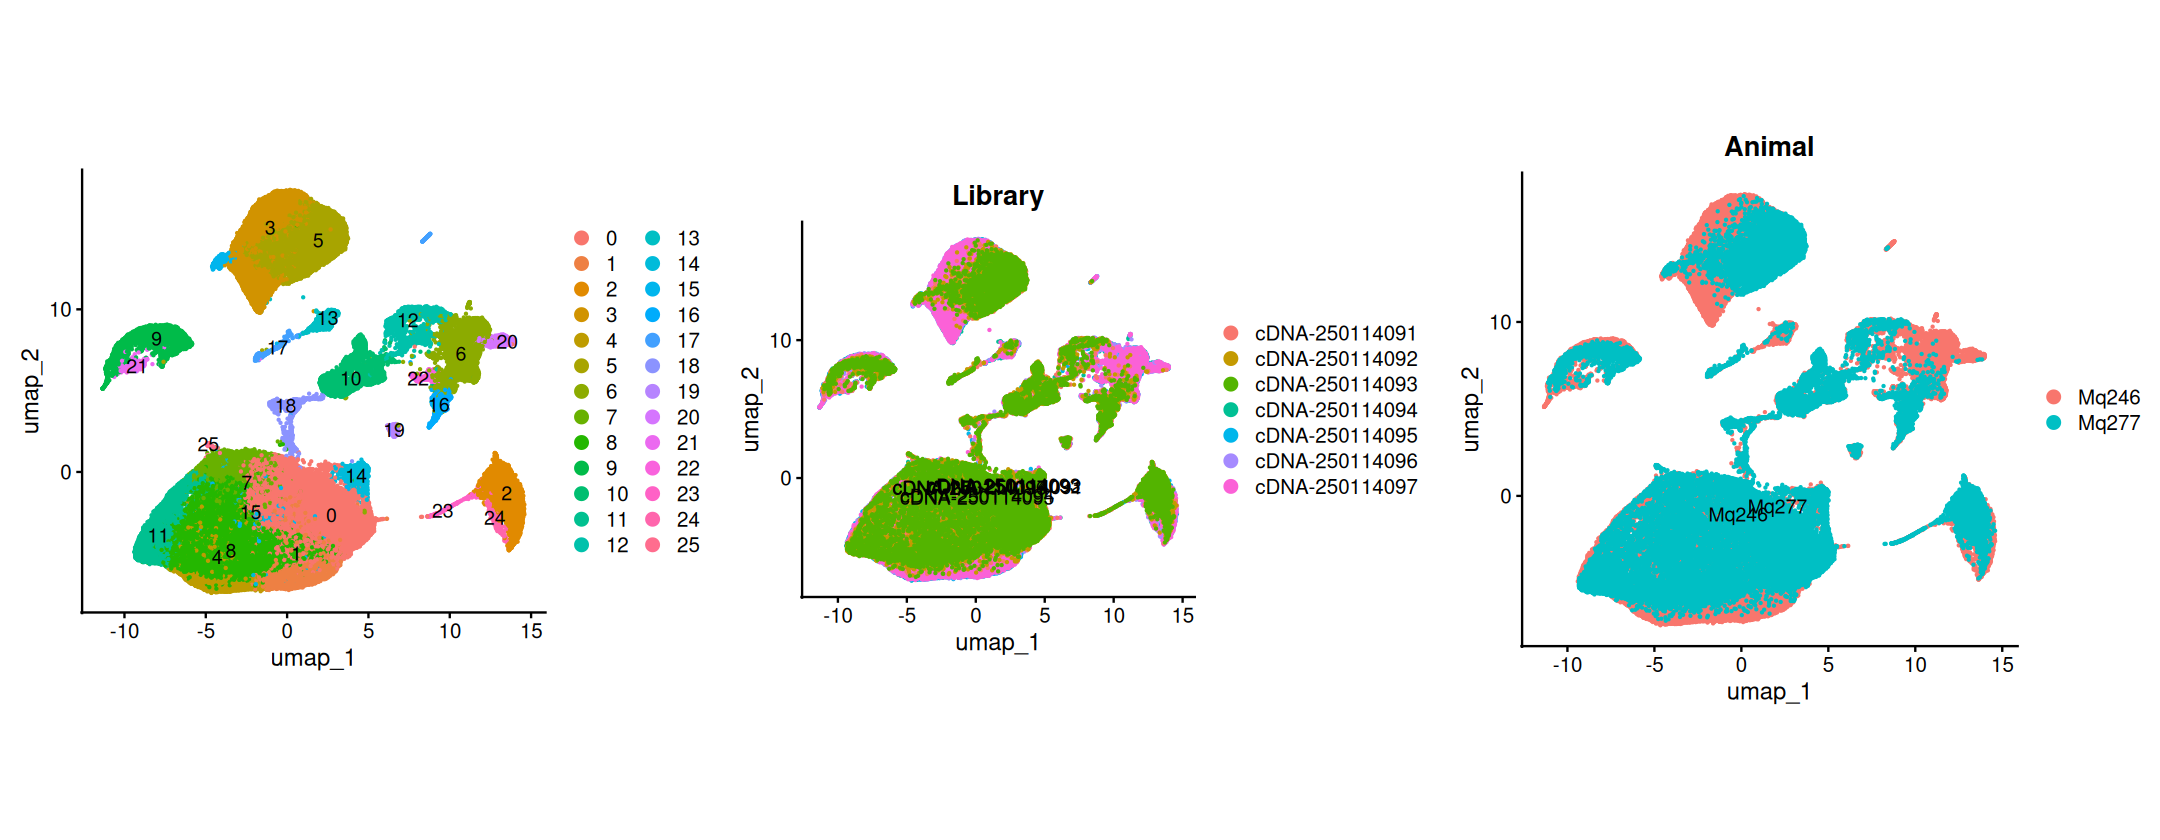

In [9]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [10]:
# 去批次
SCTseurat_harmony = SCTseurat %>%
    RunHarmony(group.by.vars = c("Animal"),dims.use = 1:25 ,theta = 2,reduction = "pca", max.iter.harmony = 10,sigma = 0.1,assay.use = "SCT", reduction.save = "harmony") %>%
    FindNeighbors(dims = 1:25, reduction = "harmony") %>%
    FindClusters(verbose = FALSE, resolution =0.5, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, reduction = "harmony", assay = "SCT")

Warning message:
“Warning: The parameter max.iter.harmony is replaced with parameter max_iter. It will be ignored for this function call and please use parameter max_iter in future function calls.
This warning is displayed once per session.”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4517050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4517050)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are pr

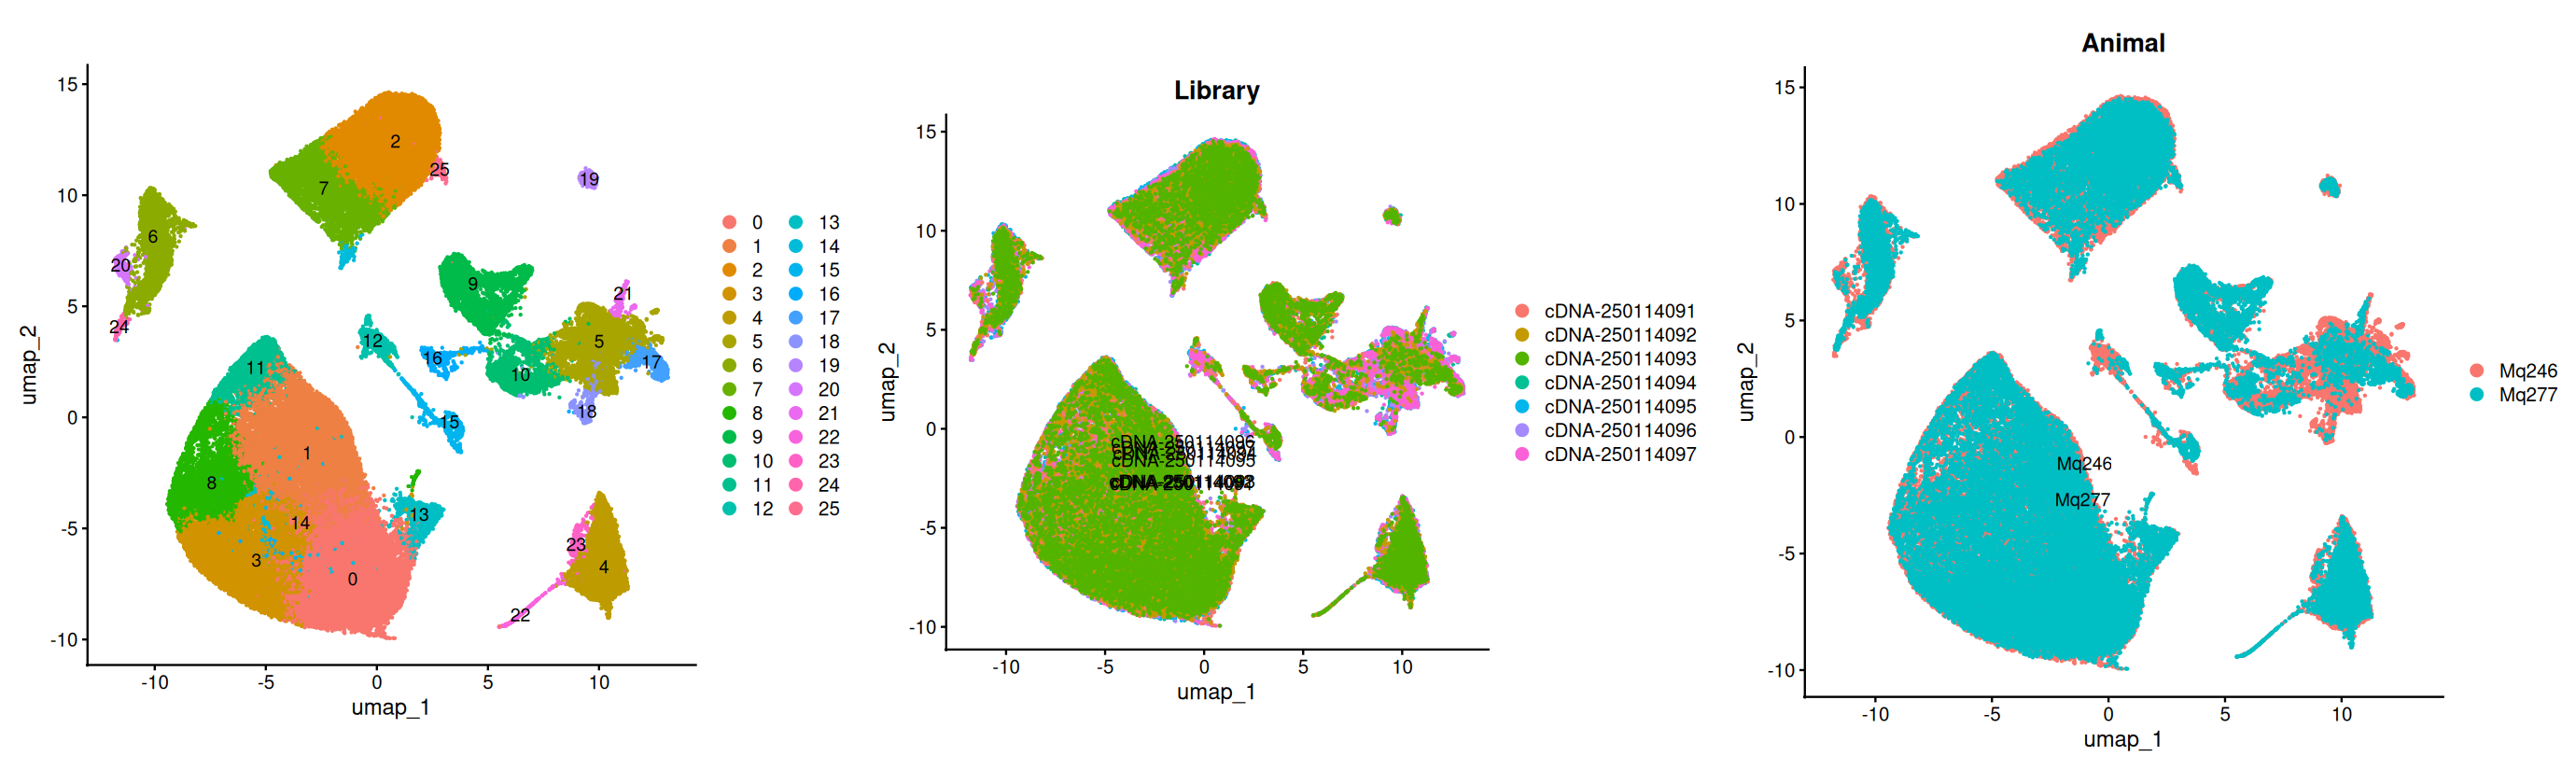

In [11]:
options(repr.plot.width=23, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [ ]:
Neuron = c('RBFOX3', 'SNAP25', 'SYT1')
DA= c('TH', 'DDC', 'SLC6A3', 'SLC18A2', 'DRD2', 'GCH1', 'PITX3', 'NR4A2')
VTA_SNc_DA = c('CALB1', 'ALDH1A1', 'SOX6', 'SNCG', 'VIP')
GABA= c('GAD1', 'GAD2', 'SLC32A1')
Glut= c('SLC17A6', 'SLC17A7', 'SLC17A8')
Astro= c( 'GFAP', 'SLC1A2', 'SLC1A3')
Oligo= c('MOBP', 'MBP', 'PLP1', 'MOG')
OPC= c('PDGFRA', 'CSPG4', 'OLIG1', 'OLIG2')
Microglia= c('CX3CR1', 'P2RY12', 'C3', 'AIF1', 'TYROBP')
Endothelial= c('CLDN5', 'FLT1', 'PECAM1', 'VWF')
Mural= c('PDGFRB', 'RGS5')
VLMC= c('DCN', 'LUM', 'COL1A1')
Ependymal= c('FOXJ1', 'TTR', 'TMEM212')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


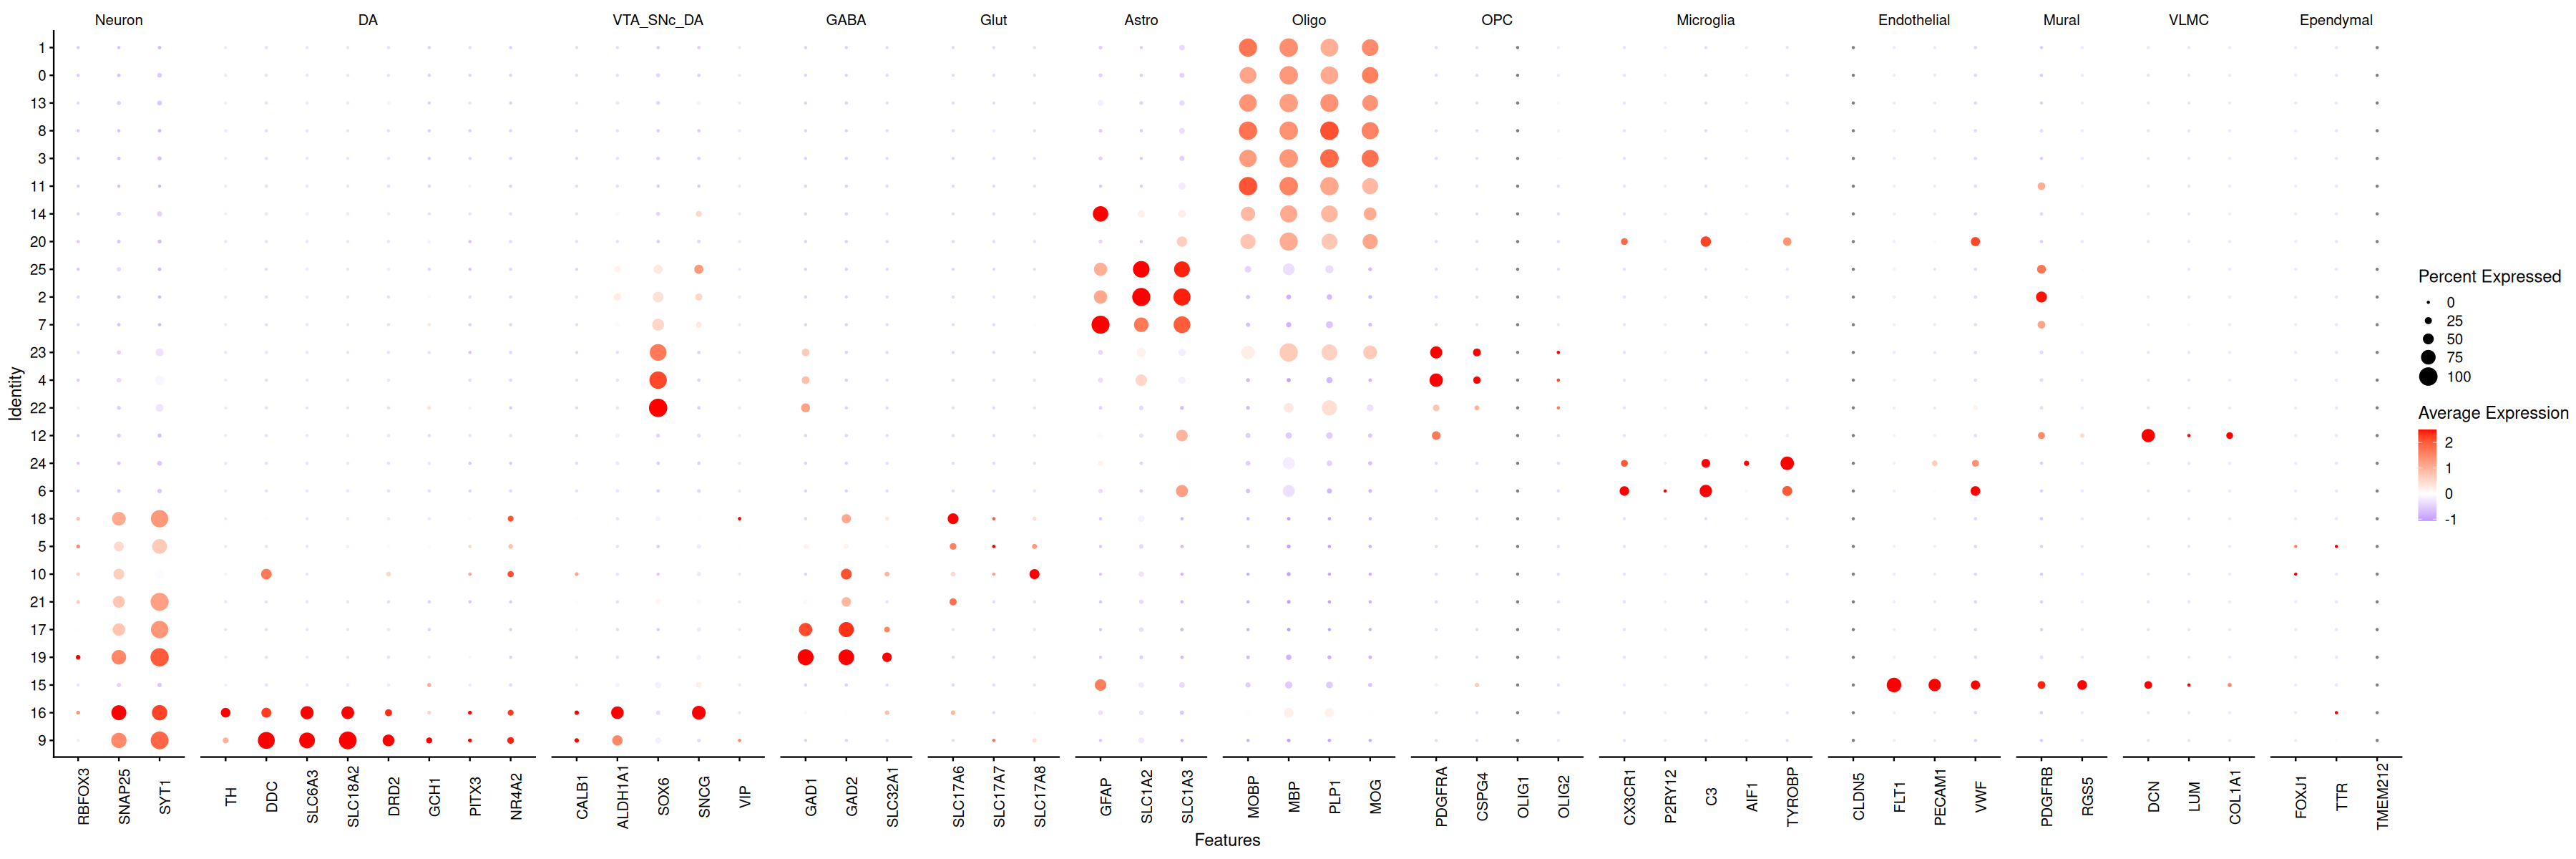

In [14]:
# selectMarkers=selectMarkers[!duplicated(selectMarkers)]
Idents(SCTseurat_harmony) = "seurat_clusters"
options(repr.plot.height=10,repr.plot.width=30)
features <- list(
"Neuron" = Neuron, 
"DA" = DA, 
"VTA_SNc_DA" = VTA_SNc_DA, 
"GABA" = GABA,  
"Glut" = Glut,
"Astro" = Astro,
"Oligo" = Oligo,
"OPC" = OPC,
"Microglia" = Microglia,
"Endothelial" = Endothelial,
"Mural" = Mural,
"VLMC" = VLMC,
"Ependymal" = Ependymal
)

features=features[!duplicated(features)]

DotPlot(SCTseurat_harmony, features = features, cluster.idents=T) + 
theme(axis.text.x = element_text(angle = 90)) +
scale_color_gradient2(low = "blue", mid = "white", high = "red")


In [16]:
SCTseurat_harmony_2 = SCTseurat_harmony

In [20]:
table(SCTseurat_harmony_2$Animal, SCTseurat_harmony_2$seurat_clusters)

       
           0    1    2    3    4    5    6    7    8    9   10   11   12   13
  Mq246 9432 6817 5408 5265 4311 5230 2588 2633 2185 1483 1693 1012  792  324
  Mq277 7782 4486 4812 4242 3772  762 2007 1400 1617 2281  584  933  164  613
       
          14   15   16   17   18   19   20   21   22   23   24   25
  Mq246  681  461  199  301  489  354  280  211  109  157  106   41
  Mq277  248  355  591  429   37  158   46   83  124   70  102   81

In [ ]:
SCTseurat_harmony_2@meta.data$class='Uncertain'

SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(19,17,21,10,5,18),]$class='Neuron'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(16,9),]$class='DA'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(7,2,25),]$class='Astro'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(14,11,3,8,13,0,1),]$class='Oligo'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(22,4,23),]$class='OPC'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(6,24,20),]$class='Micro'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(12),]$class='VLMC'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(15),]$class='Endothelial'


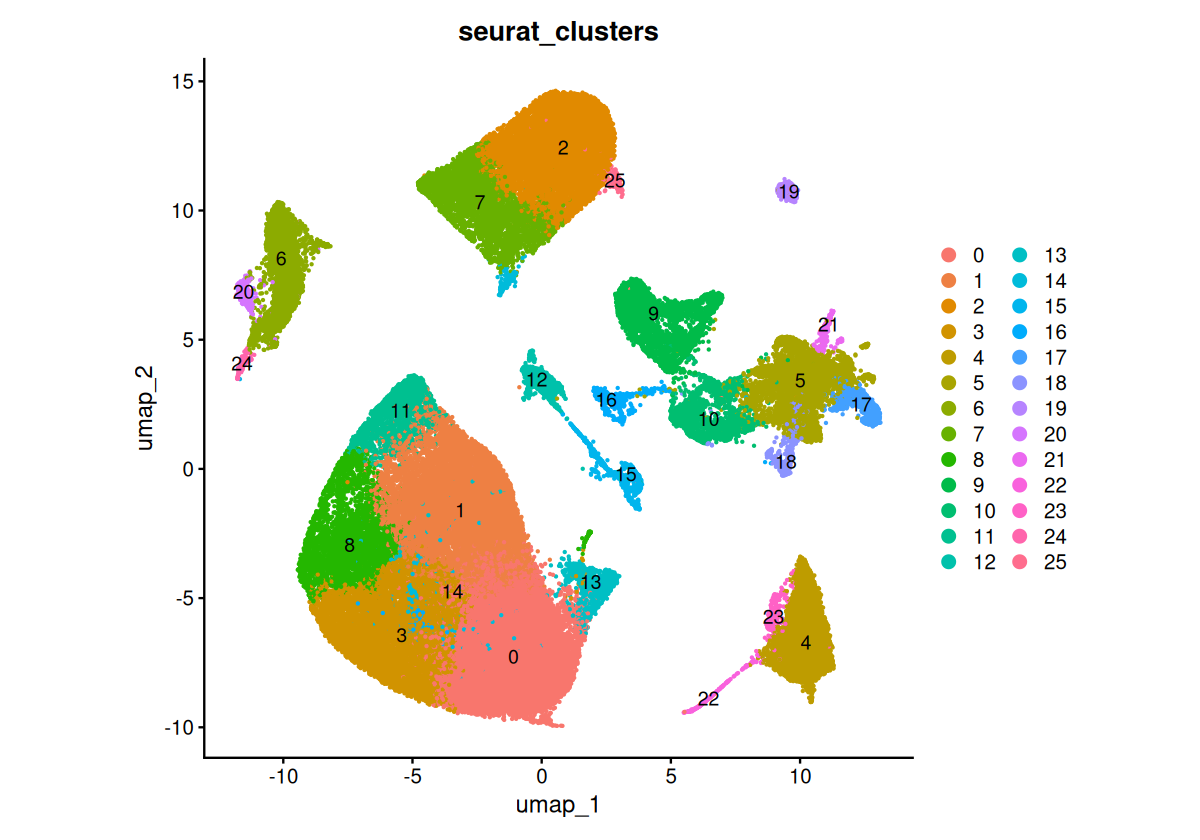

In [19]:

options(repr.plot.width=10, repr.plot.height=7)
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="seurat_clusters", label=T,raster=FALSE)+coord_fixed()

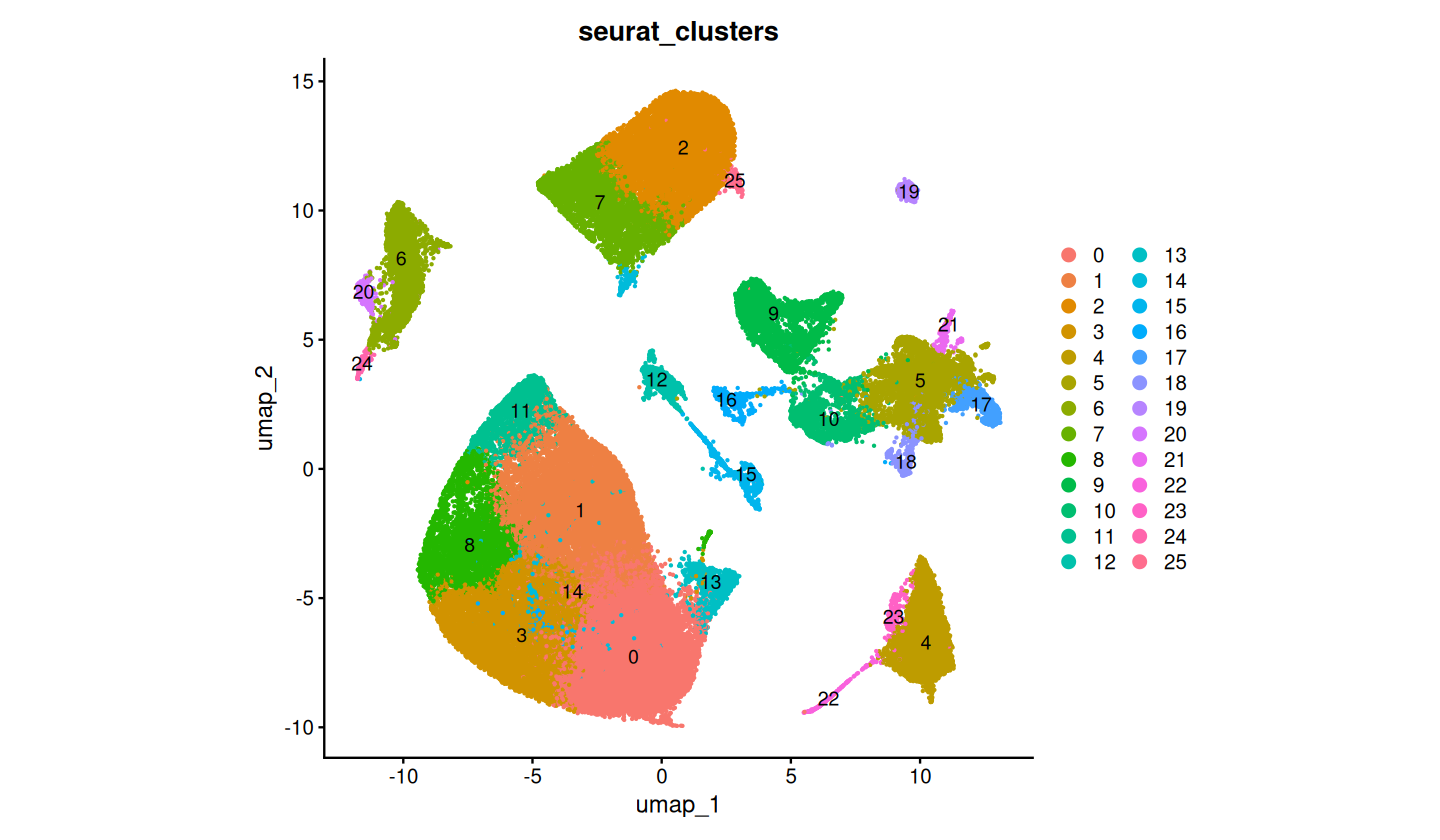

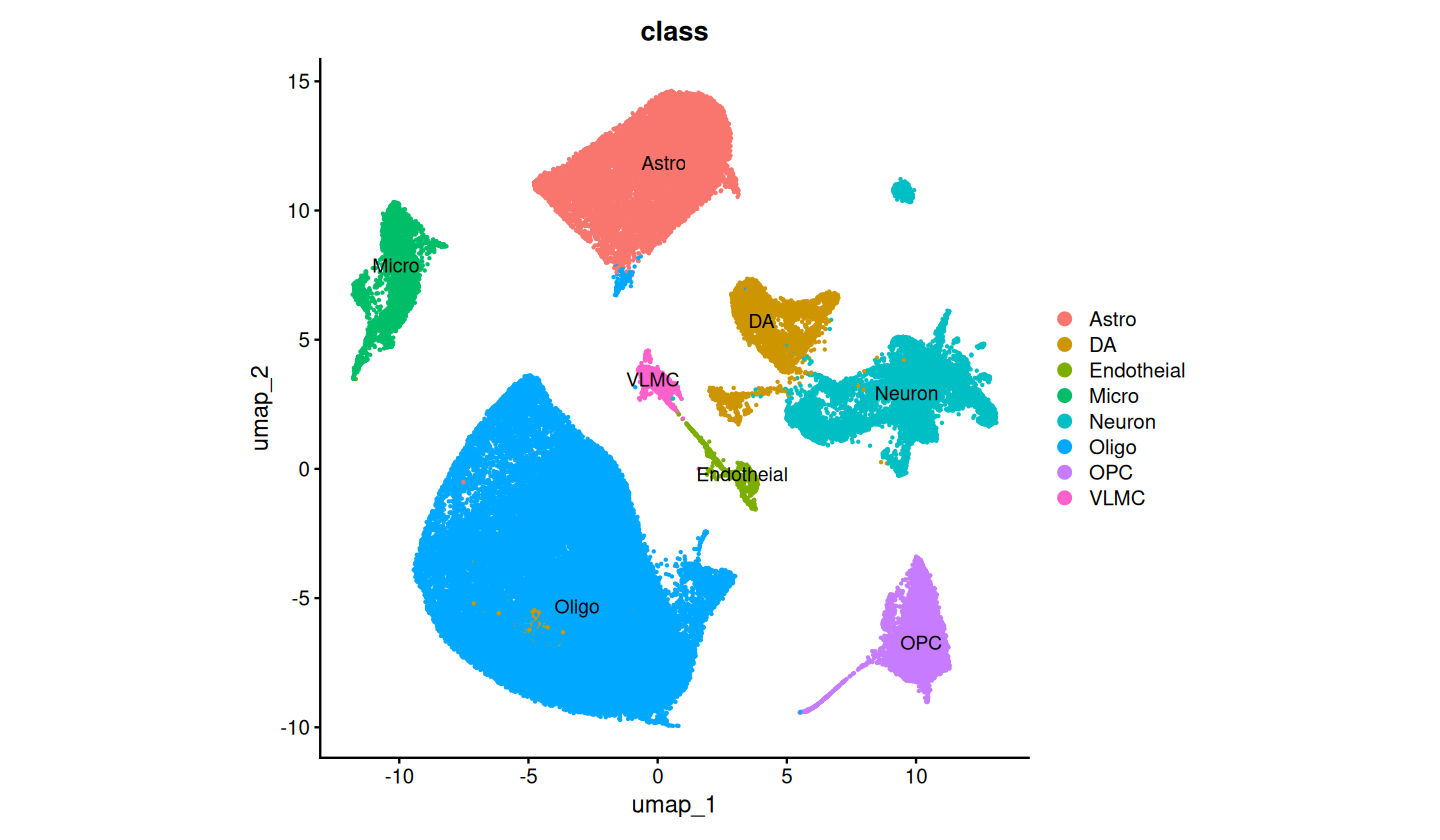

In [23]:
options(repr.plot.width=12, repr.plot.height=7)
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="seurat_clusters", label=T,raster=FALSE)+coord_fixed()
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="class", label=T,raster=FALSE)+coord_fixed()

In [24]:
sampleRatio = 0.8
maxCell = 2000
sampleDf = SCTseurat_harmony_2@meta.data[, c("class"), drop=F]
sampleList = split(sampleDf, sampleDf$class)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$class)

'data.frame':	13416 obs. of  1 variable:
 $ class: chr  "Astro" "Astro" "Astro" "Astro" ...



     Astro         DA Endotheial      Micro     Neuron      Oligo        OPC 
      2000       2000        652       2000       2000       2000       2000 
      VLMC 
       764 

In [25]:
trainSeurat = SCTseurat_harmony_2[,rownames(sampleDf)]
table(trainSeurat$class)


     Astro         DA Endotheial      Micro     Neuron      Oligo        OPC 
      2000       2000        652       2000       2000       2000       2000 
      VLMC 
       764 

Calculating cluster Oligo



Calculating cluster VLMC

Calculating cluster Neuron

Calculating cluster Micro

Calculating cluster Endotheial

Calculating cluster OPC

Calculating cluster DA

Calculating cluster Astro




     Oligo       VLMC     Neuron      Micro Endotheial        OPC         DA 
       948        757       1543       1110       2007        819        966 
     Astro 
      2139 

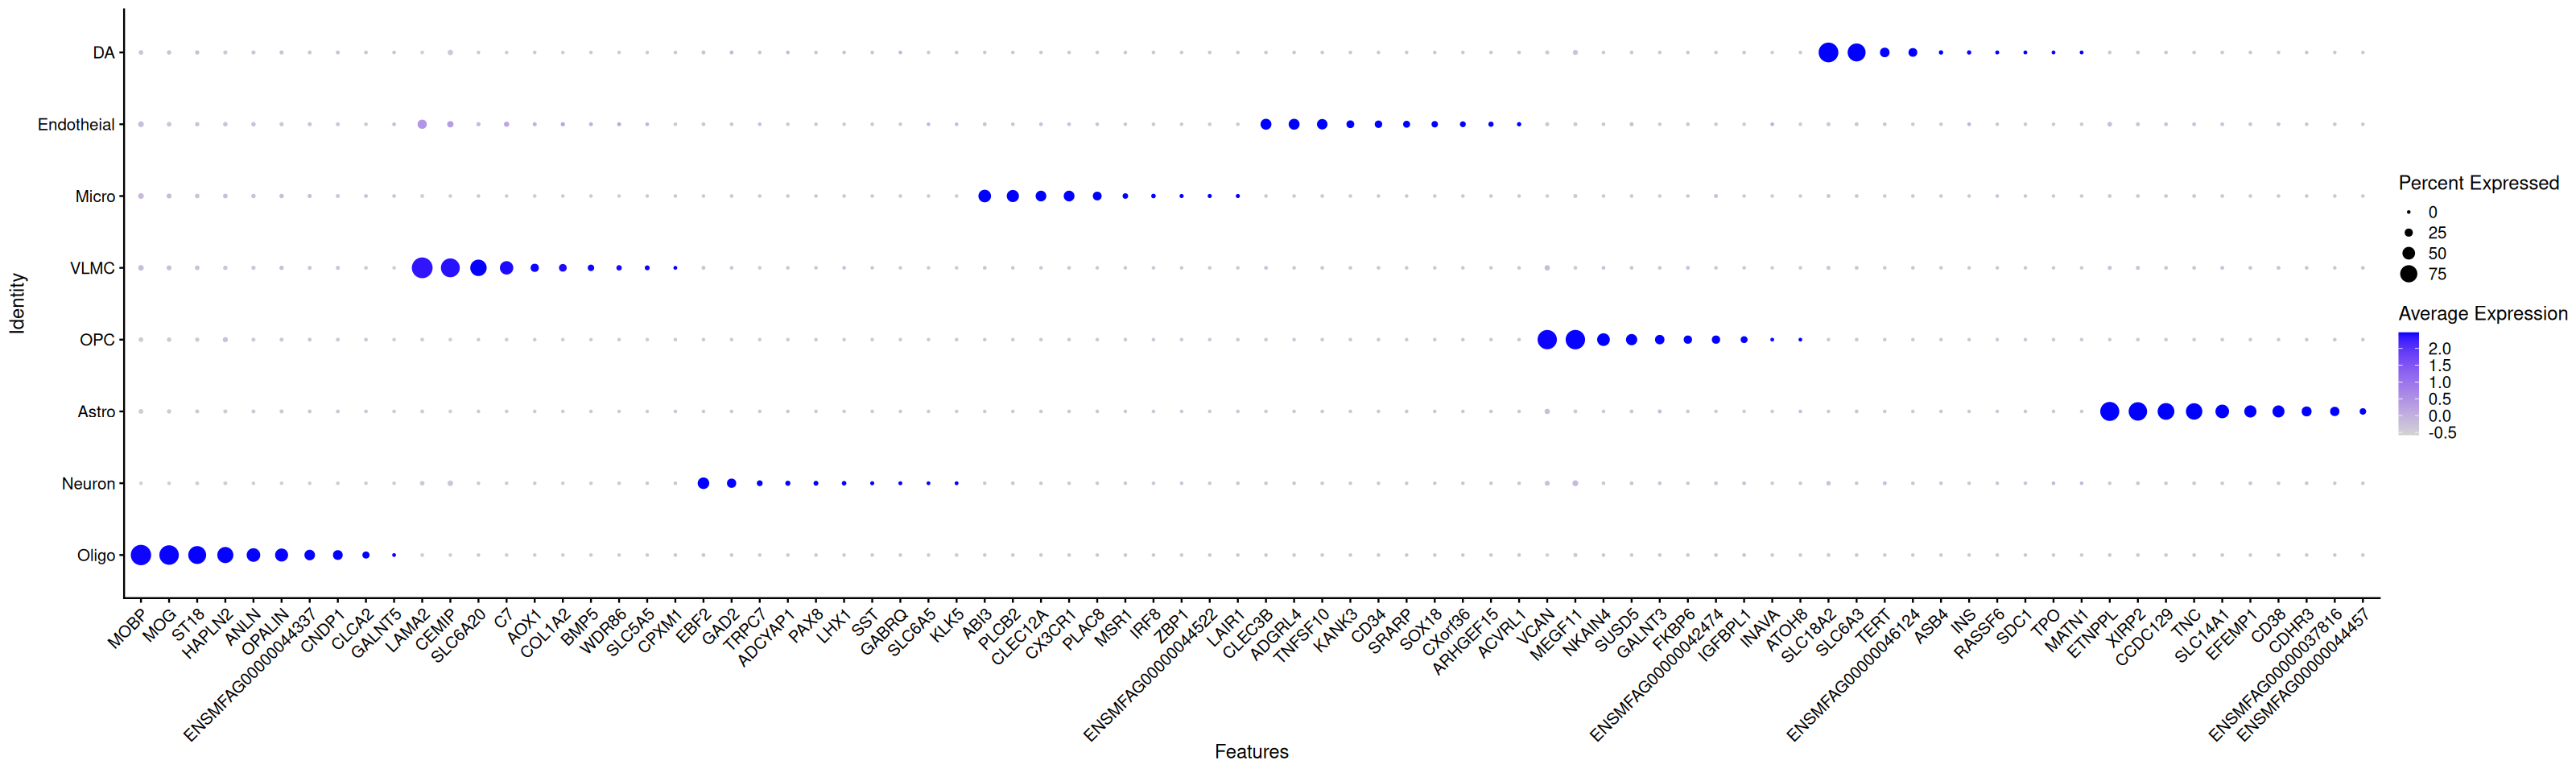

In [26]:
Idents(trainSeurat) = "class"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

classMarkerTop = classMarker %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
options(repr.plot.width=length(unique(classMarkerTop$gene))/3, repr.plot.height=8)
Idents(SCTseurat_harmony_2) = "class"
DotPlot(SCTseurat_harmony_2, features=unique(c(classMarkerTop$gene))) + RotatedAxis()

In [27]:
trainDf = as.data.frame(t(as.matrix(trainSeurat[["SCT"]]@data[unique(classMarker$gene), ])))
trainDf$class = trainSeurat$class
trainDf = subset(trainDf, class != "Uncertain")
trainDf$class = factor(trainDf$class)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_class~., data=trainDf, ntree=300)

 num [1:8, 1:9] 1999 3 2 0 0 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:8] "Astro" "DA" "Endotheial" "Micro" ...
  ..$ : chr [1:9] "Astro" "DA" "Endotheial" "Micro" ...


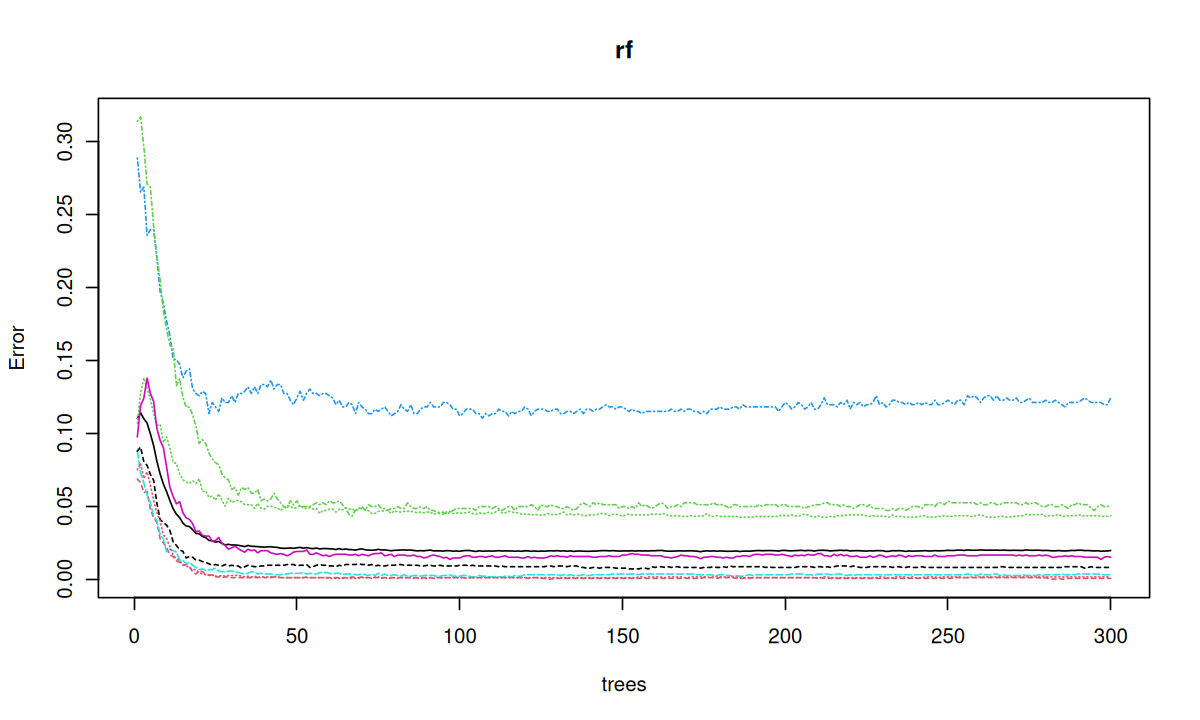

In [28]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)


In [29]:
confusionRatio = t(apply(rf$confusion[1:8, 1:8], 1, function(x) {x/sum(x)}))


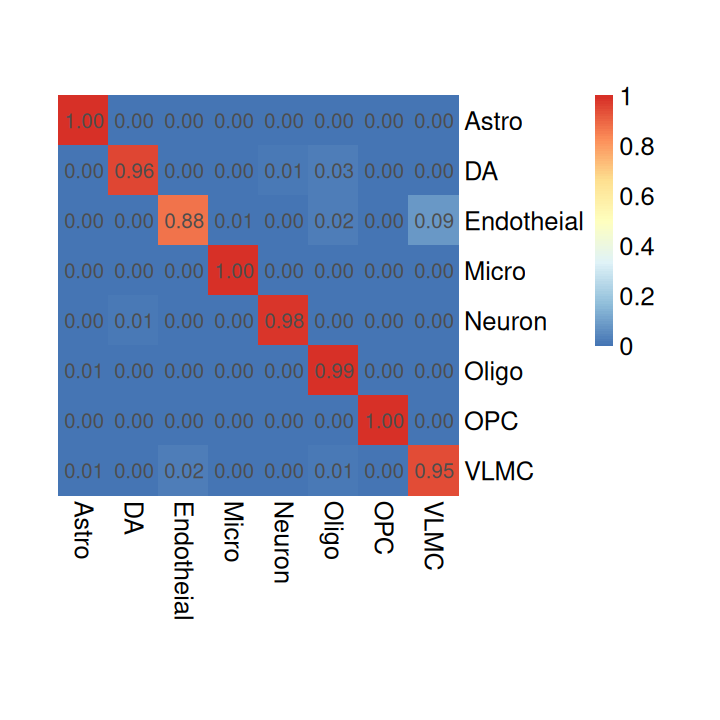

In [30]:
options(repr.plot.width=6, repr.plot.height=6)
pheatmap(confusionRatio, breaks=seq(0,1,0.01), cluster_rows=F, cluster_cols=F, border_color=NA, cellwidth=30, cellheight=30, fontsize=15,display_numbers = T)

In [31]:
seuratCountDf = as.data.frame(t(as.matrix(SCTseurat_harmony_2[["SCT"]]@data[unique(classMarker$gene), ])))

colnames(seuratCountDf) = paste0("col_", colnames(seuratCountDf))
colnames(seuratCountDf) = gsub("-", "_", colnames(seuratCountDf))
seuratClassPred = predict(rf, seuratCountDf, type="prob")
str(seuratClassPred)


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.3 GiB”


 'matrix' num [1:90341, 1:8] 0.01667 0.00667 0.00333 0.00667 0.99333 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:90341] "cDNA-250114094:CELL1_N5" "cDNA-250114094:CELL2_N4" "cDNA-250114094:CELL3_N2" "cDNA-250114094:CELL5_N4" ...
  ..$ : chr [1:8] "Astro" "DA" "Endotheial" "Micro" ...


cellId,maxPredClassScore,maxPredClass
<chr>,<dbl>,<chr>
cDNA-250114094:CELL1_N5,0.9100000,Oligo
cDNA-250114094:CELL2_N4,0.9600000,Oligo
cDNA-250114094:CELL3_N2,0.9066667,Neuron
cDNA-250114094:CELL5_N4,0.9333333,Oligo
cDNA-250114094:CELL8_N5,0.9933333,Astro
cDNA-250114094:CELL10_N4,0.8033333,Oligo


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1933  0.9033  0.9433  0.9214  0.9700  1.0000 

[1] TRUE

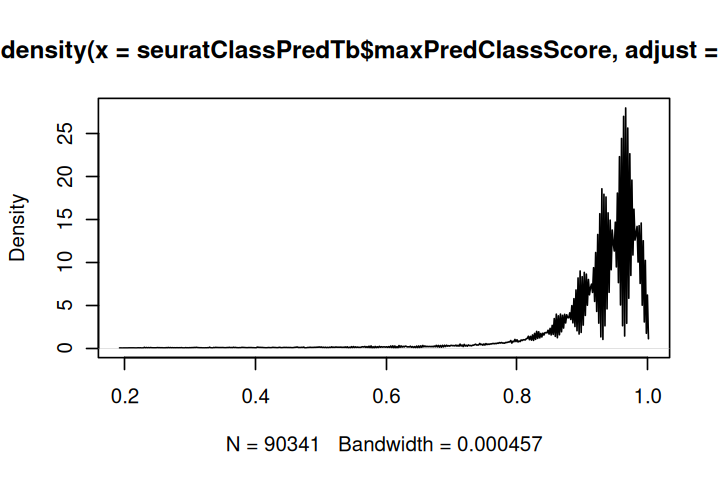

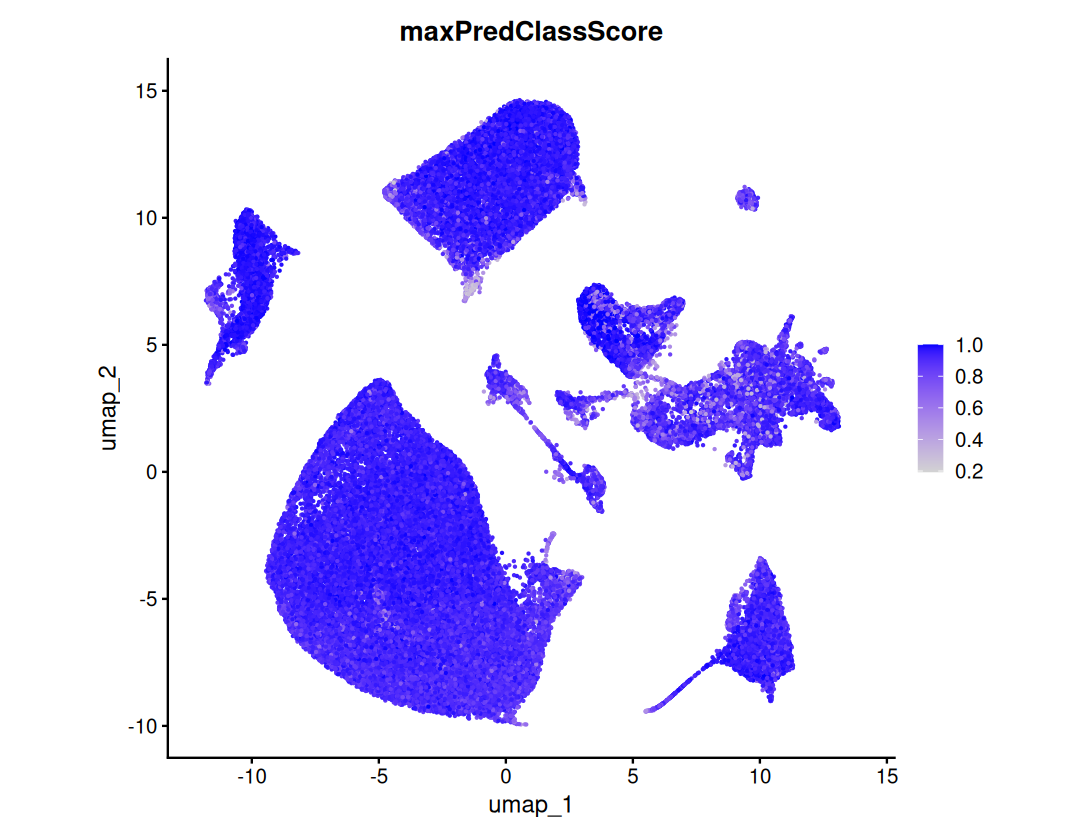

In [32]:
seuratClassPredTb = tibble(
    cellId = rownames(seuratClassPred),
    maxPredClassScore = apply(seuratClassPred, 1, max),
    maxPredClass = apply(seuratClassPred, 1, function(x) {names(x)[which.max(x)]})
)
head(seuratClassPredTb)

summary(seuratClassPredTb$maxPredClassScore)
options(repr.plot.width=6, repr.plot.height=4)
plot(density(seuratClassPredTb$maxPredClassScore, adjust=0.1))

identical(seuratClassPredTb$cellId, rownames(SCTseurat_harmony_2@meta.data))
tmpDf = as.data.frame(seuratClassPredTb[c("maxPredClassScore", "maxPredClass")])
rownames(tmpDf) = seuratClassPredTb$cellId

SCTseurat_harmony_2 = AddMetaData(SCTseurat_harmony_2, tmpDf)

options(repr.plot.width=9, repr.plot.height=7)
FeaturePlot(SCTseurat_harmony_2, reduction="umap", features="maxPredClassScore",raster=FALSE)+coord_fixed()


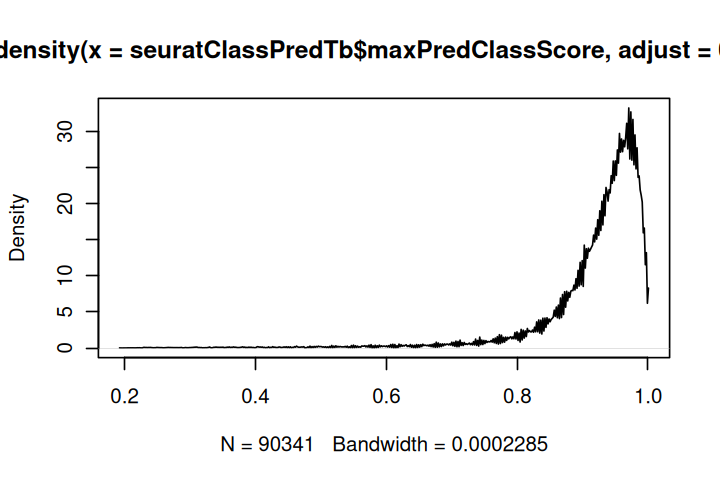

In [33]:
options(repr.plot.width=6, repr.plot.height=4)
plot(density(seuratClassPredTb$maxPredClassScore, adjust=0.05))

In [42]:
Idents(SCTseurat_harmony_2) = "seurat_clusters"
cellNum0 = ncol(SCTseurat_harmony_2)
classFiltSeurat = subset(SCTseurat_harmony_2, maxPredClassScore >= 0.8)
cellNum1 = ncol(classFiltSeurat)
message("Filt cell ratio: ", cellNum1/cellNum0)


Filt cell ratio: 0.940281821100054



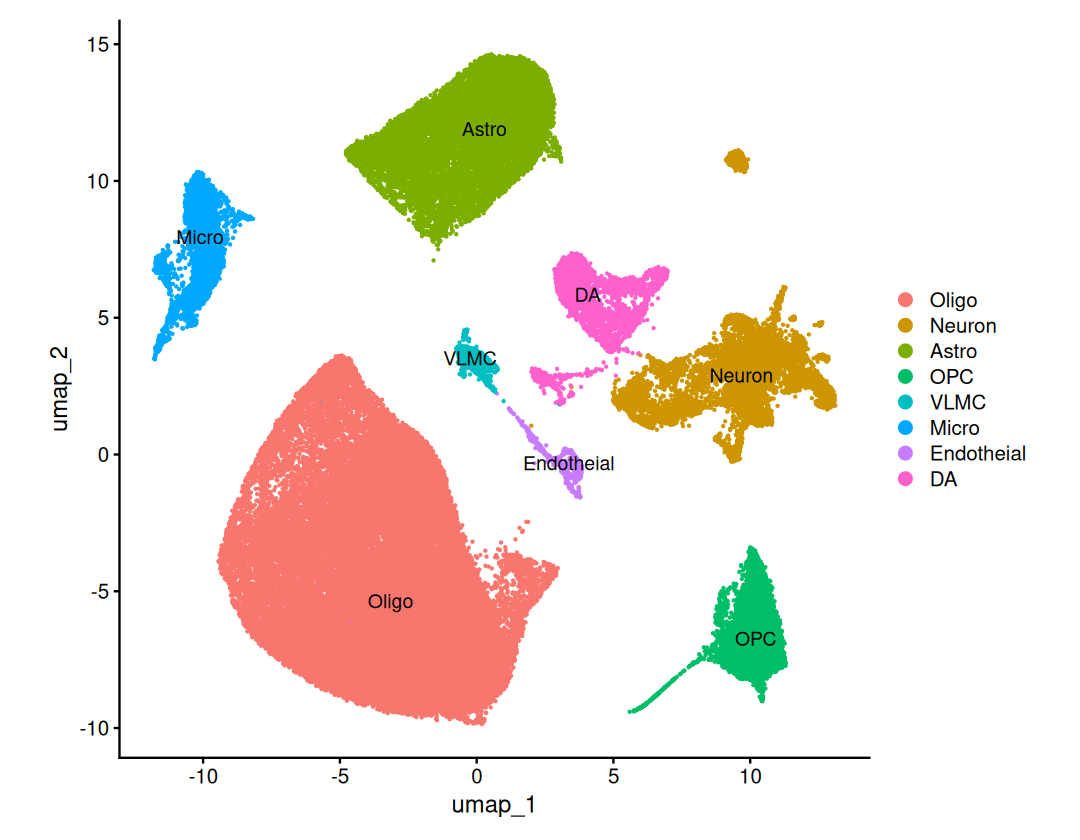

In [43]:
Idents(classFiltSeurat) = "maxPredClass"
options(repr.plot.width=9, repr.plot.height=7)
DimPlot(classFiltSeurat, reduction="umap", label=T,raster=FALSE)+coord_fixed()

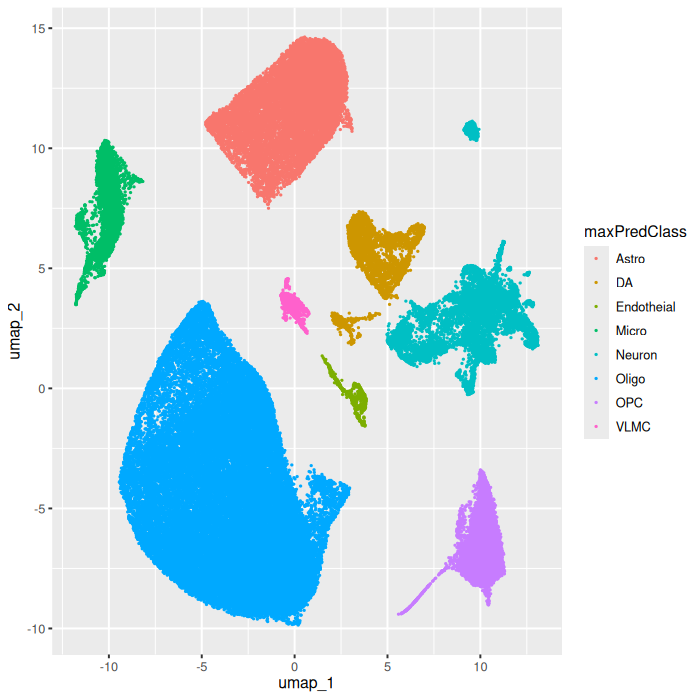

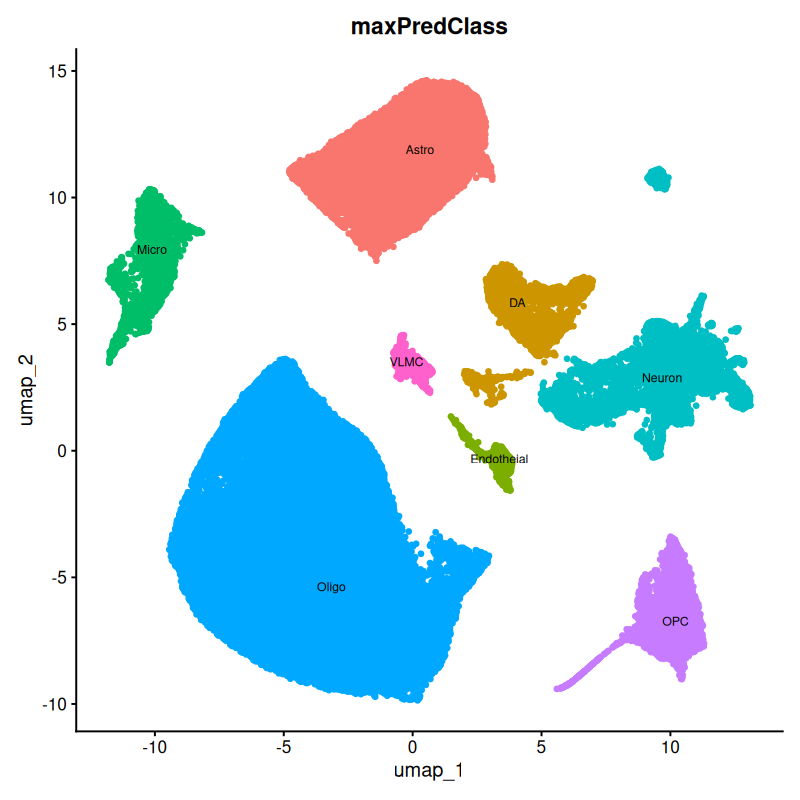

In [44]:
classFiltSeurat_filt = classFiltSeurat


umap_data <- FetchData(classFiltSeurat_filt,vars = c('umap_1','umap_2','maxPredClass'))
lapply(unique(classFiltSeurat_filt$maxPredClass), function(x){
    data <- umap_data %>% filter(maxPredClass== x)
    ### 关键参数： eps[检测范围]；minPts[当前范围内最少应包含的细胞数量]
    dbscanResult <- dbscan::dbscan(as.matrix(data[,1:2]), eps= 0.3, minPts= 10)$cluster
    return({
        rownames(data)[dbscanResult > 0]
    })
}) %>% unlist -> inlier_Cells
options(repr.plot.width = 7, repr.plot.height = 7)
umap_data[inlier_Cells,] %>% ggplot(aes(x = umap_1, y = umap_2, color = maxPredClass)) + geom_point(size = 0.01)

umap_data <- umap_data[inlier_Cells,] 
# umap_data <- umap_data[inlier_Cells,]  %>% filter(!(subclass == "VLMC|EC" & umap_1 > 4)) 

cleanUp_nc <- subset(classFiltSeurat_filt, cells = rownames(umap_data))
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 100)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = T, label.size =  3,pt.size = 1) & NoLegend() 

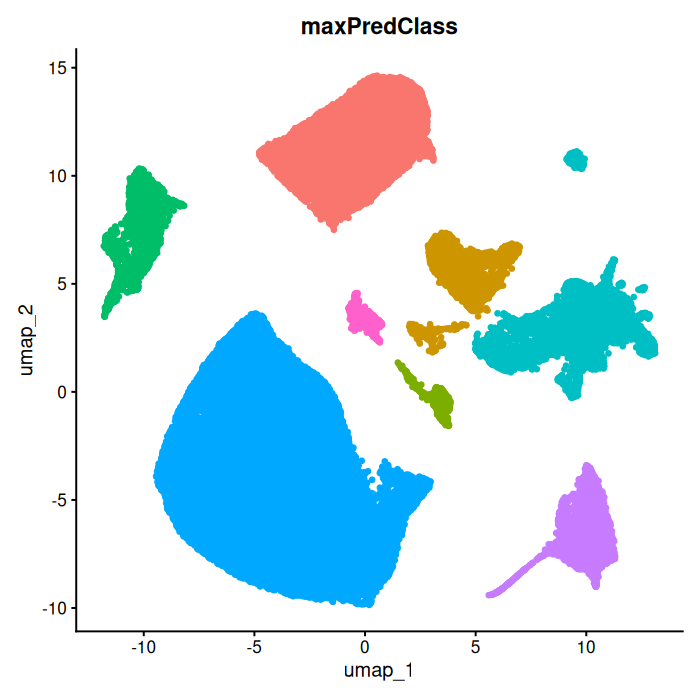

In [46]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 100)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = F, label.size =  3,pt.size = 1) & NoLegend() 

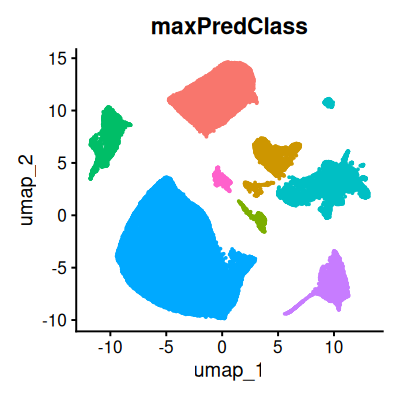

In [49]:
options(repr.plot.width = 4, repr.plot.height = 4)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = F, label.size =  3) & NoLegend() 

In [51]:
cleanUp_nc$Class = cleanUp_nc$maxPredClass

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)
DimPlot(cleanUp_nc, group.by = "Class",label = T, label.size =  3) & NoLegend() 

In [53]:
saveRDS(cleanUp_nc, "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds")